# Explore here

In [67]:
# Your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier


# Load data

In [68]:
main_df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=421&path=diabetes.csv")
main_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# Clean Data

In [69]:
# Check for missing values
print(main_df.isnull().sum())

# Check for zeros in medical columns (zeros often mean missing data)
print("\nZero values per column:")
print((main_df == 0).sum())

# Basic stats
print("\n")
print(main_df.describe())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero values per column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%      

In [70]:
# Replace zeros with NaN in medical columns
cols_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
main_df[cols_to_clean] = main_df[cols_to_clean].replace(0, np.nan)

print("Missing values after cleaning:")
print(main_df.isnull().sum())

# Fill missing values with median
main_df[cols_to_clean] = main_df[cols_to_clean].fillna(main_df[cols_to_clean].median())

print("\nZero values after cleaning:")
print((main_df == 0).sum())

Missing values after cleaning:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Zero values after cleaning:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


# Split Data

In [71]:
train_df,test_df= train_test_split(main_df,test_size=0.25, random_state=4)

In [72]:
X_train = train_df.drop(columns=['Outcome'])
y_train = train_df['Outcome']

X_test = test_df.drop(columns=['Outcome'])
y_test = test_df['Outcome']

# Evaluator function

In [73]:
def model_evaluator(X_matrix, y_target, model):
    preds = model.predict(X_matrix)
    
    print(f"Accuracy score: {round(accuracy_score(y_true = y_target, y_pred = preds),4)}")
    print(f"Precision score: {round(precision_score(y_true = y_target, y_pred = preds),4)}")
    print(f"Recall score: {round(recall_score(y_true = y_target, y_pred = preds),4)}")
    print(f"F1 score:{round(f1_score(y_true = y_target, y_pred = preds),4)}")
    print(f"Confusion matrix: \n{confusion_matrix(y_true = y_target, y_pred = preds)}")
    print(f"Classification report: \n{classification_report(y_true = y_target, y_pred = preds)}")

In [74]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=101)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [75]:
model_evaluator(X_test, y_test, rf_model)

Accuracy score: 0.776
Precision score: 0.6575
Recall score: 0.7273
F1 score:0.6906
Confusion matrix: 
[[101  25]
 [ 18  48]]
Classification report: 
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       126
           1       0.66      0.73      0.69        66

    accuracy                           0.78       192
   macro avg       0.75      0.76      0.76       192
weighted avg       0.78      0.78      0.78       192



# Feature importance

In [76]:
np.round(pd.DataFrame(rf_model.feature_importances_,rf_model.feature_names_in_)*100,2)

,0
Pregnancies,8.42
Glucose,22.88
BloodPressure,8.82
SkinThickness,7.95
Insulin,8.55
BMI,16.24
DiabetesPedigreeFunction,12.13
Age,15.01


# Model 2 - Gradient Boosting

In [77]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [78]:
model_evaluator(X_train, y_train, gb_model)

Accuracy score: 0.9288
Precision score: 0.9259
Recall score: 0.8663
F1 score:0.8951
Confusion matrix: 
[[360  14]
 [ 27 175]]
Classification report: 
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       374
           1       0.93      0.87      0.90       202

    accuracy                           0.93       576
   macro avg       0.93      0.91      0.92       576
weighted avg       0.93      0.93      0.93       576



# Model 3 - XGBoost

In [79]:
xgb_model = XGBClassifier (random_state=101)
xgb_model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [80]:
model_evaluator(X_test,y_test,xgb_model)

Accuracy score: 0.7604
Precision score: 0.6389
Recall score: 0.697
F1 score:0.6667
Confusion matrix: 
[[100  26]
 [ 20  46]]
Classification report: 
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       126
           1       0.64      0.70      0.67        66

    accuracy                           0.76       192
   macro avg       0.74      0.75      0.74       192
weighted avg       0.77      0.76      0.76       192



# GridSearchCV for XGBoost

In [81]:
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100],
    'max_depth': [3, 6],
}

In [82]:
gridsearch_model = GridSearchCV(
    estimator=XGBClassifier(random_state=101),
    param_grid=param_grid,
    scoring='accuracy',
    verbose=3,
    cv=4
)

In [83]:
gridsearch_model.fit(X_train,y_train)

Fitting 4 folds for each of 12 candidates, totalling 48 fits
[CV 1/4] END learning_rate=0.01, max_depth=3, n_estimators=50;, score=0.729 total time=   0.0s
[CV 2/4] END learning_rate=0.01, max_depth=3, n_estimators=50;, score=0.694 total time=   0.0s
[CV 3/4] END learning_rate=0.01, max_depth=3, n_estimators=50;, score=0.729 total time=   0.0s
[CV 4/4] END learning_rate=0.01, max_depth=3, n_estimators=50;, score=0.701 total time=   0.0s
[CV 1/4] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=0.764 total time=   0.0s
[CV 2/4] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=0.694 total time=   0.0s
[CV 3/4] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=0.701 total time=   0.0s
[CV 4/4] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=0.708 total time=   0.0s
[CV 1/4] END learning_rate=0.01, max_depth=6, n_estimators=50;, score=0.729 total time=   0.0s
[CV 2/4] END learning_rate=0.01, max_depth=6, n_estimators=50;, score=0.708 tota

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 6], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [84]:
gridsearch_model.fit(X_train, y_train)
print("Best parameters:", gridsearch_model.best_params_)
print("Best accuracy:", gridsearch_model.best_score_)

Fitting 4 folds for each of 12 candidates, totalling 48 fits
[CV 1/4] END learning_rate=0.01, max_depth=3, n_estimators=50;, score=0.729 total time=   0.0s
[CV 2/4] END learning_rate=0.01, max_depth=3, n_estimators=50;, score=0.694 total time=   0.0s
[CV 3/4] END learning_rate=0.01, max_depth=3, n_estimators=50;, score=0.729 total time=   0.0s
[CV 4/4] END learning_rate=0.01, max_depth=3, n_estimators=50;, score=0.701 total time=   0.0s
[CV 1/4] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=0.764 total time=   0.0s
[CV 2/4] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=0.694 total time=   0.0s
[CV 3/4] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=0.701 total time=   0.0s
[CV 4/4] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=0.708 total time=   0.0s
[CV 1/4] END learning_rate=0.01, max_depth=6, n_estimators=50;, score=0.729 total time=   0.0s
[CV 2/4] END learning_rate=0.01, max_depth=6, n_estimators=50;, score=0.708 tota

# Best model evaluation

In [85]:
best_xgb = gridsearch_model.best_estimator_
print("=== Best XGBoost (Test) ===")
model_evaluator(X_test, y_test, best_xgb)

=== Best XGBoost (Test) ===
Accuracy score: 0.776
Precision score: 0.6769
Recall score: 0.6667
F1 score:0.6718
Confusion matrix: 
[[105  21]
 [ 22  44]]
Classification report: 
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       126
           1       0.68      0.67      0.67        66

    accuracy                           0.78       192
   macro avg       0.75      0.75      0.75       192
weighted avg       0.78      0.78      0.78       192



#  Visualizations

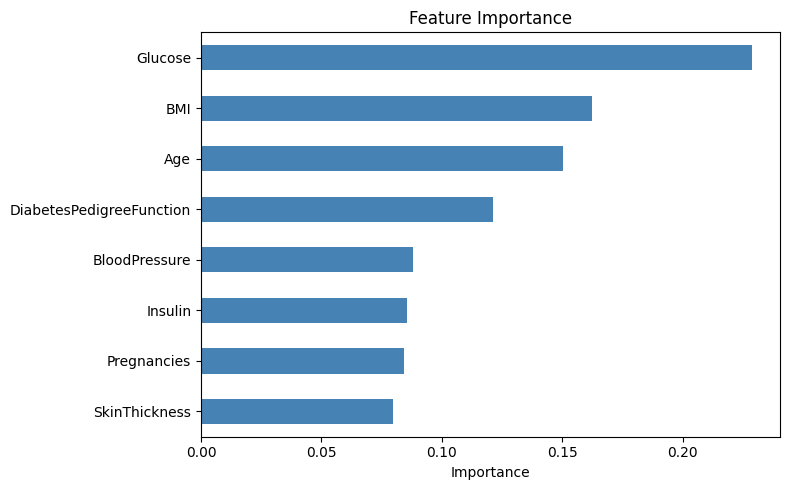

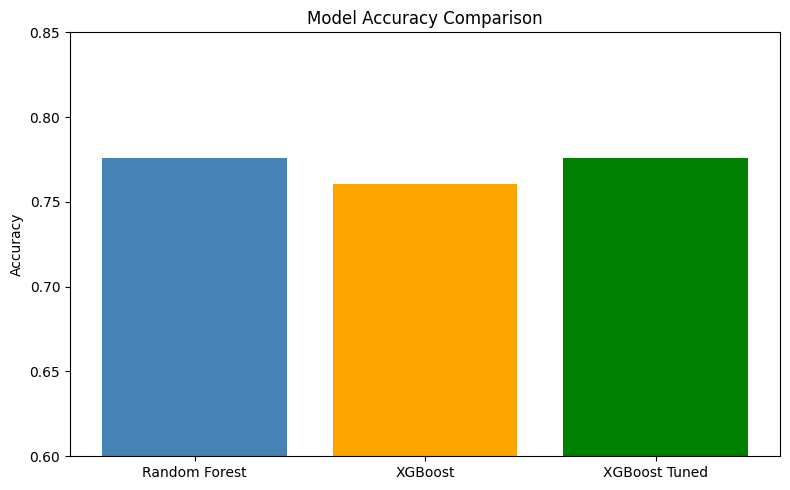

In [87]:
# 1. Feature Importance
feat_imp = pd.DataFrame(rf_model.feature_importances_, 
                        index=rf_model.feature_names_in_, 
                        columns=['Importance']).sort_values('Importance')

feat_imp.plot(kind='barh', figsize=(8, 5), color='steelblue', legend=False)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# 2. Model Comparison - updated with clean data results
models = ['Random Forest', 'XGBoost', 'XGBoost Tuned']
accuracies = [0.776, 0.7604, 0.776]  # updated numbers

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['steelblue', 'orange', 'green'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.6, 0.85)
plt.tight_layout()
plt.show()